<a href="https://colab.research.google.com/github/archangel2006/Quantinel/blob/main/4b_quantum_open_world_attack_characterization_(smaller_sample).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Quantum Open-World Characterization**

Can quantum kernel embeddings effectively characterize known network intrusion families under an open-world setting containing both known and previously unseen attacks?

## **Imports**

In [80]:
# %pip install -U \
# qiskit \
# qiskit-machine-learning \
# qiskit-aer \
# pylatexenc \
# matplotlib

print("done")

done


In [81]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler
)

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SelectKBest
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Quantum
from qiskit.circuit.library import ZZFeatureMap

from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_machine_learning.algorithms import QSVC

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## **Load Datatsets**

In [82]:
import pandas as pd

train = pd.read_csv("KDDTrain.csv")
test = pd.read_csv("KDDTest.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (125973, 43)
Test Shape  : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## **Open-World Analysis**

In [83]:

print("Train Attack Types")
train_attacks = sorted(train["label"].unique())
print(train_attacks)

print("\nTotal:", len(train_attacks))

Train Attack Types
['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'spy', 'teardrop', 'warezclient', 'warezmaster']

Total: 23


In [84]:
print("Test Attack Types")
test_attacks = sorted(test["label"].unique())
print(test_attacks)

print("\nTotal:", len(test_attacks))


Test Attack Types
['apache2', 'back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'ipsweep', 'land', 'loadmodule', 'mailbomb', 'mscan', 'multihop', 'named', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'processtable', 'ps', 'rootkit', 'saint', 'satan', 'sendmail', 'smurf', 'snmpgetattack', 'snmpguess', 'sqlattack', 'teardrop', 'udpstorm', 'warezmaster', 'worm', 'xlock', 'xsnoop', 'xterm']

Total: 38


In [85]:
known = sorted(set(train_attacks) & set(test_attacks))
new = sorted(set(test_attacks) - set(train_attacks))

print("Known Attack Types")
print(known)
print("Count:", len(known))

print("\nPreviously Unseen Attack Types")
print(new)
print("Count:", len(new))

Known Attack Types
['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'teardrop', 'warezmaster']
Count: 21

Previously Unseen Attack Types
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']
Count: 17


### **Map Attacks to Attack Families**

In [86]:

dos = [
    "back","land","neptune","pod",
    "smurf","teardrop"
]

probe = [
    "ipsweep","nmap",
    "portsweep","satan"
]

r2l = [
    "ftp_write","guess_passwd","imap",
    "multihop","phf","spy",
    "warezclient","warezmaster"
]

u2r = [
    "buffer_overflow",
    "loadmodule",
    "perl",
    "rootkit"
]


family_map = {}

for a in dos:
    family_map[a]="dos"

for a in probe:
    family_map[a]="probe"

for a in r2l:
    family_map[a]="r2l"

for a in u2r:
    family_map[a]="u2r"

train["family"] = train["label"].map(family_map)

attack_df = train.dropna(subset=["family"]).copy()

print("Attack Records :",attack_df.shape[0])

print()

print(attack_df["family"].value_counts())

Attack Records : 58630

family
dos      45927
probe    11656
r2l        995
u2r         52
Name: count, dtype: int64


In [87]:
# Training labels
train["family"] = train["label"].map(family_map)

# Testing labels
test["family"] = test["label"].map(family_map)

In [88]:
print(train["family"].isna().sum())
print(test["family"].isna().sum())

67343
13461


In [89]:
test["family"] = (
    test["label"]
    .map(family_map)
    .fillna("unknown")
)

In [90]:
test.head(3)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,family
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.06,0.00,0.00,0.0,0.0,1.0,1.0,neptune,21,dos
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.06,0.00,0.00,0.0,0.0,1.0,1.0,neptune,21,dos
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.04,0.61,0.02,0.0,0.0,0.0,0.0,normal,21,unknown


In [91]:
# Dataset A: DoS + Probe + R2L


dataset_A = attack_df[
    attack_df["family"]!="u2r"
].copy()

df1 = dataset_A.copy()



# Dataset B: Includes U2R


dataset_B = attack_df.copy()

df2 = dataset_B.copy()


# Print

print("Dataset A")

print(dataset_A.family.value_counts())

print()

print("Dataset B")

print(dataset_B.family.value_counts())

Dataset A
family
dos      45927
probe    11656
r2l        995
Name: count, dtype: int64

Dataset B
family
dos      45927
probe    11656
r2l        995
u2r         52
Name: count, dtype: int64


### **Working Datatset**

In [92]:
# Dataset 1

x1 = df1.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y1 = df1["family"]

# Dataset 2

x2 = df2.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y2 = df2["family"]

print("Dataset 1:", x1.shape)
print("Dataset 2:", x2.shape)

Dataset 1: (58578, 41)
Dataset 2: (58630, 41)


## **OneHot Encoding + MinMax Scaling**


In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler


cat_cols = [
    "protocol_type",
    "service",
    "flag"
]



# Dataset A

num_cols1 = [
    c
    for c in x1.columns
    if c not in cat_cols
]

preprocessor1 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            MinMaxScaler(),
            num_cols1
        )
    ]
)

x_processed1 = preprocessor1.fit_transform(x1)

feature_names1 = preprocessor1.get_feature_names_out()

x_processed1 = pd.DataFrame(
    x_processed1,
    columns=feature_names1
)

print("Dataset A Encoded Shape :", x_processed1.shape)



# Dataset B

num_cols2 = [
    c
    for c in x2.columns
    if c not in cat_cols
]

preprocessor2 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            MinMaxScaler(),
            num_cols2
        )
    ]
)

x_processed2 = preprocessor2.fit_transform(x2)

feature_names2 = preprocessor2.get_feature_names_out()

x_processed2 = pd.DataFrame(
    x_processed2,
    columns=feature_names2
)

print("Dataset B Encoded Shape :", x_processed2.shape)



Dataset A Encoded Shape : (58578, 118)
Dataset B Encoded Shape : (58630, 118)


In [94]:
x_processed1.head()

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_IRC,cat__service_X11,cat__service_Z39_50,cat__service_aol,cat__service_auth,cat__service_bgp,cat__service_courier,...,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_serror_rate,num__dst_host_srv_serror_rate,num__dst_host_rerror_rate,num__dst_host_srv_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.098425,0.10,0.05,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.070866,0.07,0.07,0.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.031496,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.055118,0.06,0.07,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.086614,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0


In [95]:
x_processed2.head()

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_IRC,cat__service_X11,cat__service_Z39_50,cat__service_aol,cat__service_auth,cat__service_bgp,cat__service_courier,...,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_serror_rate,num__dst_host_srv_serror_rate,num__dst_host_rerror_rate,num__dst_host_srv_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.098425,0.10,0.05,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.070866,0.07,0.07,0.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.031496,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.055118,0.06,0.07,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.086614,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0


## **Remove Near-Constant Features**

In [96]:
from sklearn.feature_selection import VarianceThreshold


# Dataset A

print("Dataset A - Original Features :", x_processed1.shape[1])

var_filter1 = VarianceThreshold(
    threshold=0.01
)

x_var1 = var_filter1.fit_transform(x_processed1)

selected_features1 = x_processed1.columns[
    var_filter1.get_support()
]

x_var1 = pd.DataFrame(
    x_var1,
    columns=selected_features1
)

print("Dataset A - Remaining Features :", x_var1.shape[1])



# Dataset B

print("\nDataset B - Original Features :", x_processed2.shape[1])

var_filter2 = VarianceThreshold(
    threshold=0.01
)

x_var2 = var_filter2.fit_transform(x_processed2)

selected_features2 = x_processed2.columns[
    var_filter2.get_support()
]

x_var2 = pd.DataFrame(
    x_var2,
    columns=selected_features2
)

print("Dataset B - Remaining Features :", x_var2.shape[1])

Dataset A - Original Features : 118
Dataset A - Remaining Features : 49

Dataset B - Original Features : 118
Dataset B - Remaining Features : 49


## **Remove Highly Correlated Features**


In [97]:
# Dataset A

corr_matrix1 = x_var1.corr().abs()

upper1 = corr_matrix1.where(
    np.triu(
        np.ones(corr_matrix1.shape),
        k=1
    ).astype(bool)
)

drop_cols1 = [
    column
    for column in upper1.columns
    if any(
        upper1[column] > 0.95
    )
]

print("Dataset A - Highly Correlated Features :", len(drop_cols1))

x_corr1 = x_var1.drop(
    columns=drop_cols1
)

print("Dataset A - Remaining Features :", x_corr1.shape[1])



# Dataset B

corr_matrix2 = x_var2.corr().abs()

upper2 = corr_matrix2.where(
    np.triu(
        np.ones(corr_matrix2.shape),
        k=1
    ).astype(bool)
)

drop_cols2 = [
    column
    for column in upper2.columns
    if any(
        upper2[column] > 0.95
    )
]

print("\nDataset B - Highly Correlated Features :", len(drop_cols2))

x_corr2 = x_var2.drop(
    columns=drop_cols2
)

print("Dataset B - Remaining Features :", x_corr2.shape[1])

Dataset A - Highly Correlated Features : 6
Dataset A - Remaining Features : 43

Dataset B - Highly Correlated Features : 6
Dataset B - Remaining Features : 43


In [98]:
display(x_corr1.head())
display(x_corr2.head())

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_Z39_50,cat__service_auth,cat__service_bgp,cat__service_courier,cat__service_eco_i,cat__service_ecr_i,cat__service_finger,...,num__same_srv_rate,num__diff_srv_rate,num__srv_diff_host_rate,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.07,0.0,1.0,0.098425,0.10,0.05,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.16,0.06,0.0,1.0,0.070866,0.07,0.07,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.06,0.0,1.0,0.031496,0.04,0.05,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.14,0.06,0.0,1.0,0.055118,0.06,0.07,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.09,0.05,0.0,1.0,0.086614,0.09,0.05,0.0,0.0,0.0


,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_Z39_50,cat__service_auth,cat__service_bgp,cat__service_courier,cat__service_eco_i,cat__service_ecr_i,cat__service_finger,...,num__same_srv_rate,num__diff_srv_rate,num__srv_diff_host_rate,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.07,0.0,1.0,0.098425,0.10,0.05,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.16,0.06,0.0,1.0,0.070866,0.07,0.07,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.06,0.0,1.0,0.031496,0.04,0.05,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.14,0.06,0.0,1.0,0.055118,0.06,0.07,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.09,0.05,0.0,1.0,0.086614,0.09,0.05,0.0,0.0,0.0


## **Top Informative Features**


Feature selection is performed once on the closed-world dataset. The resulting feature rankings are also used for Dataset B since the inclusion of 52 U2R samples produces negligible changes in Mutual Information.

In [99]:
from sklearn.feature_selection import mutual_info_classif


mi_scores = mutual_info_classif(
    x_corr1,
    y1,
    random_state=42
)

mi = pd.Series(
    mi_scores,
    index=x_corr1.columns
)

mi = mi.sort_values(
    ascending=False
)

print("Top 20 Features")
display(mi.head(20))

Top 20 Features


,0
num__dst_host_diff_srv_rate,0.355595
num__count,0.316533
num__diff_srv_rate,0.314197
cat__flag_S0,0.230182
num__same_srv_rate,0.225018
num__dst_host_same_src_port_rate,0.223524
num__srv_count,0.208817
num__dst_host_same_srv_rate,0.203977
num__dst_host_srv_count,0.179202
num__dst_host_count,0.157293


In [100]:
mi.to_csv("mutual_information_scores.csv")

## **Select Top 8 Features**


In [101]:
TOP_K = 8

top_features = mi.head(TOP_K).index.tolist()

print("Selected Features")

for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")

# Dataset A
x_selected = x_corr1[
    top_features
].copy()

# Dataset B
x_selected2 = x_corr2[
    top_features
].copy()

print()

print("Dataset A Final Quantum Shape")
print(x_selected.shape)

print()

print("Dataset B Final Quantum Shape")
print(x_selected2.shape)

Selected Features
1. num__dst_host_diff_srv_rate
2. num__count
3. num__diff_srv_rate
4. cat__flag_S0
5. num__same_srv_rate
6. num__dst_host_same_src_port_rate
7. num__srv_count
8. num__dst_host_same_srv_rate

Dataset A Final Quantum Shape
(58578, 8)

Dataset B Final Quantum Shape
(58630, 8)


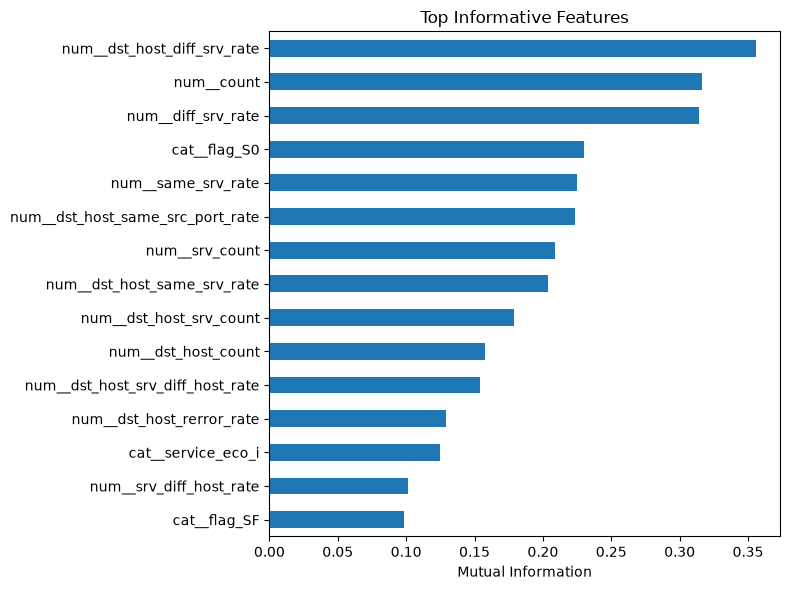

In [102]:
plt.figure(figsize=(8,6))

mi.head(15).sort_values().plot(kind="barh")

plt.xlabel("Mutual Information")
plt.title("Top Informative Features")

plt.tight_layout()

plt.savefig(
    "top_features.png",
    dpi=300
)

plt.show()

| Feature                         | Why it's useful                                                                         |
| ------------------------------- | --------------------------------------------------------------------------------------- |
| **flag_S0**                     | Connection status. S0 means SYN sent but no reply. Very discriminative for DoS attacks. |
| **count**                       | Number of connections to the same host. Excellent attack indicator.                     |
| **srv_count**                   | Connections to same service. Separates scanning vs flooding.                            |
| **same_srv_rate**               | Fraction of same-service connections. Important for attack behavior.                    |
| **diff_srv_rate**               | Fraction of different-service connections. Very useful for Probe attacks.               |
| **dst_host_same_srv_rate**      | Destination host service consistency. Common IDS feature.                               |
| **dst_host_diff_srv_rate**      | Destination host diversity. Helps distinguish Probe/R2L.                                |
| **dst_host_same_src_port_rate** | Source-port reuse pattern. Another classical intrusion feature.                         |


The algorithm selected them using:

- Variance filtering
- Correlation filtering
- Mutual Information



> *After removing low-variance and highly correlated features, Mutual Information was employed to retain the eight most informative engineered network features for quantum embedding.*

## **Balanced Quantum Dataset**


In [103]:
# Dataset A (DoS + Probe + R2L)

quantum_df1 = x_selected.copy()
quantum_df1["family"] = y1.values

dos1 = quantum_df1[quantum_df1.family == "dos"].sample(
    120,
    random_state=42
)

probe1 = quantum_df1[quantum_df1.family == "probe"].sample(
    120,
    random_state=42
)

r2l1 = quantum_df1[quantum_df1.family == "r2l"].sample(
    120,
    random_state=42
)

quantum_df1 = pd.concat([
    dos1,
    probe1,
    r2l1
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X1 = quantum_df1.drop(columns="family")
Y1 = quantum_df1["family"]

print("Dataset A")
print(X1.shape)
print(Y1.value_counts())


Dataset A
(360, 8)
family
probe    120
dos      120
r2l      120
Name: count, dtype: int64


In [104]:
# Dataset B (DoS + Probe + R2L + U2R)

quantum_df2 = x_selected2.copy()
quantum_df2["family"] = y2.values

dos2 = quantum_df2[quantum_df2.family == "dos"].sample(
    120,
    random_state=42
)

probe2 = quantum_df2[quantum_df2.family == "probe"].sample(
    120,
    random_state=42
)

r2l2 = quantum_df2[quantum_df2.family == "r2l"].sample(
    120,
    random_state=42
)

# Use all available U2R samples (52)
u2r2 = quantum_df2[quantum_df2.family == "u2r"]

quantum_df2 = pd.concat([
    dos2,
    probe2,
    r2l2,
    u2r2
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X2 = quantum_df2.drop(columns="family")
Y2 = quantum_df2["family"]

print("\nDataset B")
print(X2.shape)
print(Y2.value_counts())


Dataset B
(412, 8)
family
r2l      120
dos      120
probe    120
u2r       52
Name: count, dtype: int64


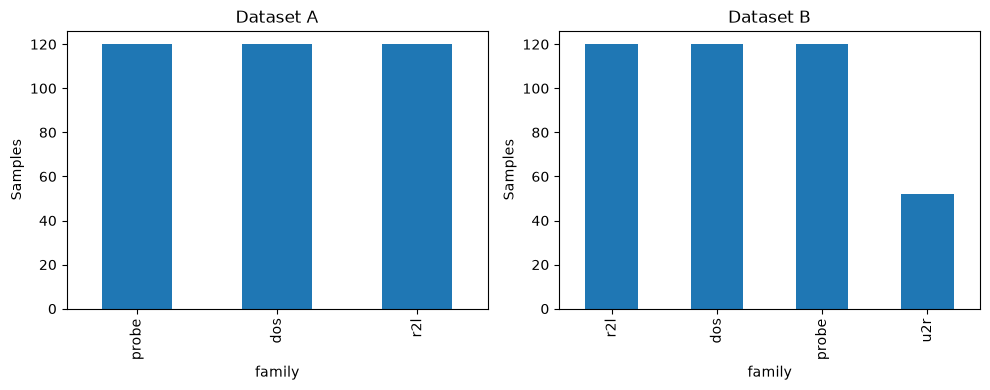

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

Y1.value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Dataset A")
axes[0].set_ylabel("Samples")

Y2.value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Dataset B")
axes[1].set_ylabel("Samples")

plt.tight_layout()
plt.savefig(
    "balanced_datasets.png",
    dpi=300
)
plt.show()

In [106]:
print("Open-World Test Set")
print("Shape :", test.shape)

print("\nFamily Distribution")
print(test["family"].value_counts())

print("\nKnown Families")
print(test[test["family"] != "unknown"]["family"].value_counts())

print("\nUnknown Attack Samples")
print((test["family"] == "unknown").sum())

Open-World Test Set
Shape : (22544, 44)

Family Distribution
family
unknown    13461
dos         5741
r2l         2199
probe       1106
u2r           37
Name: count, dtype: int64

Known Families
family
dos      5741
r2l      2199
probe    1106
u2r        37
Name: count, dtype: int64

Unknown Attack Samples
13461


## **Quantum Feature Map**

In [107]:
from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(
    feature_dimension=X1.shape[1],
    reps=1
)

print(feature_map)

fig = feature_map.decompose().draw("mpl")

fig.savefig(
    "ZZFeatureMap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

     ┌────────────────────────────────────────────────────────┐
q_0: ┤0                                                       ├
     │                                                        │
q_1: ┤1                                                       ├
     │                                                        │
q_2: ┤2                                                       ├
     │                                                        │
q_3: ┤3                                                       ├
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5],x[6],x[7]) │
q_4: ┤4                                                       ├
     │                                                        │
q_5: ┤5                                                       ├
     │                                                        │
q_6: ┤6                                                       ├
     │                                                        │
q_7: ┤7                                 

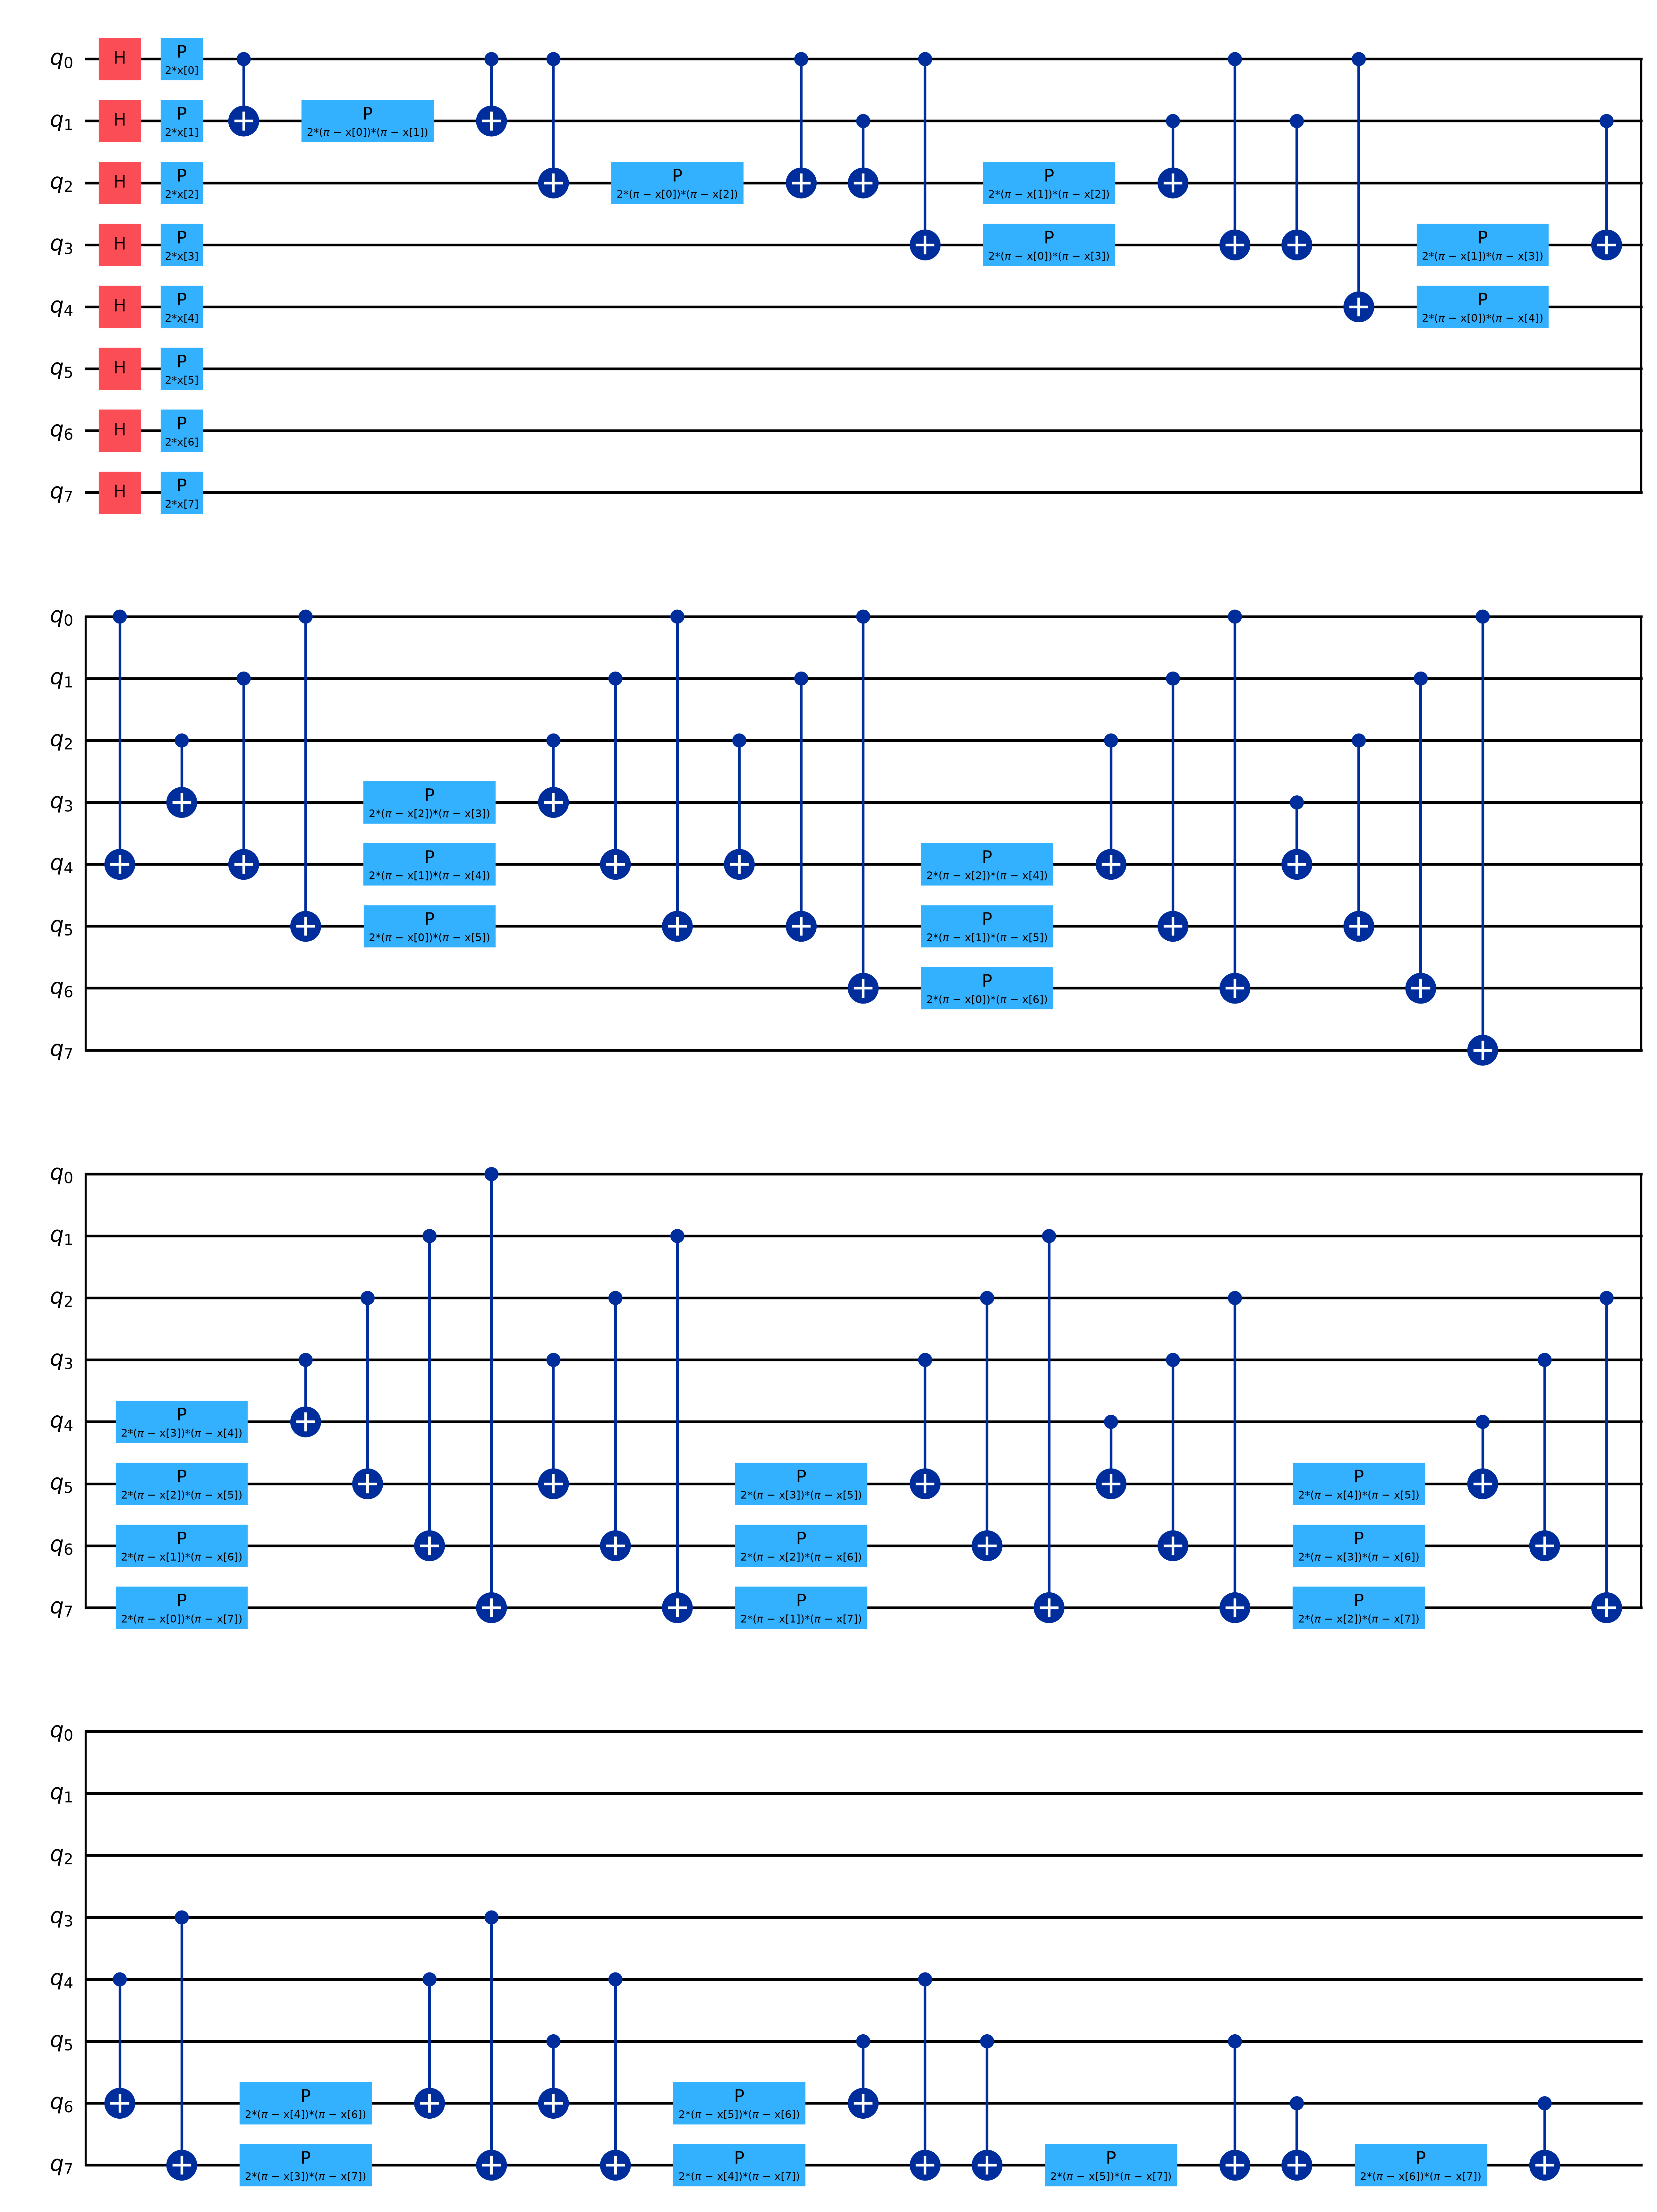

In [108]:
import qiskit
import qiskit_machine_learning

print(qiskit.__version__)
print(qiskit_machine_learning.__version__)

2.5.0
0.9.0


In [109]:
print("Dataset A")
print(X1.shape)
print(type(X1))

print(Y1.shape)
print(Y1.value_counts())

Dataset A
(360, 8)
<class 'pandas.core.frame.DataFrame'>
(360,)
family
probe    120
dos      120
r2l      120
Name: count, dtype: int64


In [110]:
print("Dataset B")
print(X2.shape)
print(type(X2))

print(Y2.shape)
print(Y2.value_counts())

Dataset B
(412, 8)
<class 'pandas.core.frame.DataFrame'>
(412,)
family
r2l      120
dos      120
probe    120
u2r       52
Name: count, dtype: int64


In [111]:
print(np.isnan(X1).sum())
print(np.isinf(X1).sum())

num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64
num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64


In [112]:
print(np.isnan(X1).sum())
print(np.isinf(X2).sum())

num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64
num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64


In [113]:
print(feature_map.num_qubits)

8


## **Fidelity Quantum Kernel Construction**

In [114]:
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
print("Imported successfully!")

quantum_kernel = FidelityStatevectorKernel(
    feature_map=feature_map
)

print("Kernel Ready")

Imported successfully!
Kernel Ready


In [115]:
# from qiskit_aer import AerSimulator
# from qiskit.primitives import StatevectorSampler
# from qiskit_machine_learning.state_fidelities import ComputeUncompute
# from qiskit_machine_learning.kernels import FidelityQuantumKernel

# sampler = StatevectorSampler()

# fidelity = ComputeUncompute(
#     sampler=sampler
# )

# quantum_kernel = FidelityQuantumKernel(
#     feature_map=feature_map,
#     fidelity=fidelity
# )

# print("Kernel Ready")

In [116]:
import qiskit_aer
print(qiskit_aer.__version__)

0.17.2


In [117]:
from time import time

start = time()

K = quantum_kernel.evaluate(X1.iloc[:20])

print("Time:", time()-start)

Time: 0.1197206974029541


In [118]:
print(type(quantum_kernel))
print(type(feature_map))

<class 'qiskit_machine_learning.kernels.fidelity_statevector_kernel.FidelityStatevectorKernel'>
<class 'qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap'>


In [119]:
import time

start = time.time()
K = quantum_kernel.evaluate(X1.iloc[:5])
print(time.time() - start)

0.035945892333984375


## **QSVC Training**

In [120]:
from qiskit_machine_learning.algorithms import QSVC
import joblib

# Dataset A

qsvc1 = QSVC(
    quantum_kernel=quantum_kernel
)

print("Training QSVC - Dataset A...")

qsvc1.fit(
    X1,
    Y1
)

joblib.dump(
    qsvc1,
    "qsvc_dataset_A.pkl"
)

print("Dataset A Training Complete.")


# Dataset B

qsvc2 = QSVC(
    quantum_kernel=quantum_kernel
)

print("\nTraining QSVC - Dataset B...")

qsvc2.fit(
    X2,
    Y2
)

joblib.dump(
    qsvc2,
    "qsvc_dataset_B.pkl"
)

print("Dataset B Training Complete.")

Training QSVC - Dataset A...
Dataset A Training Complete.

Training QSVC - Dataset B...
Dataset B Training Complete.


## **Prediction**

In [121]:
# import joblib

# qsvc1 = joblib.load("qsvc_dataset_A.pkl")
# qsvc2 = joblib.load("qsvc_dataset_B.pkl")

# print("QSVC models loaded successfully.")

In [122]:
print("Dataset A support vectors:", len(qsvc1.support_))
print("Dataset B support vectors:", len(qsvc2.support_))

print(qsvc1.n_support_)
print(qsvc2.n_support_)

Dataset A support vectors: 178
Dataset B support vectors: 246
[49 75 54]
[50 77 73 46]


In [123]:
start = time.time()
_ = quantum_kernel.evaluate(X1.iloc[:20])
print(time.time()-start)

0.13659048080444336


In [124]:
import time

start = time.time()
K = quantum_kernel.evaluate(X1.iloc[:20], X1.iloc[:20])
print("20x20 kernel:", time.time() - start)

20x20 kernel: 0.1287217140197754


In [125]:
import time

start = time.time()
_ = qsvc1.predict(x_test1.iloc[:1])
print("1 sample:", time.time() - start)

1 sample: 1.6124649047851562


In [126]:
import time

start = time.time()
_ = qsvc1.predict(x_test1.iloc[:5])
print("5 samples:", time.time() - start)

5 samples: 1.6316378116607666


In [127]:
# print(type(qsvc1.quantum_kernel))
# print(type(qsvc1.quantum_kernel.fidelity))
# print(type(qsvc1.quantum_kernel.fidelity.sampler))

In [128]:
import sklearn
print(sklearn.__version__)

1.6.1


In [129]:
print(qsvc1.quantum_kernel)

In [130]:
# # Representative evaluation subset

# SAMPLES_PER_FAMILY = 200

# test_subset = (
#     test.groupby("family", group_keys=False)
#     .apply(
#         lambda x: x.sample(
#             n=min(len(x), SAMPLES_PER_FAMILY),
#             random_state=42
#         )
#     )
#     .reset_index(drop=True)
# )

# print(test_subset["family"].value_counts())

In [131]:
test_eval = (
    test.groupby("family", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5), random_state=42))
    .reset_index(drop=True)
)

In [132]:
# ---------------- Dataset A ----------------

test_known_A = test_eval[
    test_eval["family"] != "u2r"
].copy()

x_test1 = test_known_A.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y_test1 = test_known_A["family"]


# ---------------- Dataset B ----------------

test_known_B = test_eval.copy()

x_test2 = test_known_B.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y_test2 = test_known_B["family"]

In [133]:
# ----------------- Datatset A ------------

x_test1 = preprocessor1.transform(x_test1)
x_test1 = pd.DataFrame(
    x_test1,
    columns=feature_names1
)

x_test1 = x_test1[selected_features1]
x_test1 = x_test1.drop(columns=drop_cols1)
x_test1 = x_test1[top_features]


# ----------------- Datatset B ------------

x_test2 = preprocessor2.transform(x_test2)
x_test2 = pd.DataFrame(
    x_test2,
    columns=feature_names2
)

x_test2 = x_test2[selected_features2]
x_test2 = x_test2.drop(columns=drop_cols2)
x_test2 = x_test2[top_features]

In [134]:
import time

start = time.time()

_ = qsvc1.predict(x_test1.iloc[:20])

print(f"{time.time()-start:.2f} seconds")

1.77 seconds


In [135]:
print(len(x_test1))
print(len(x_test2))

20
25


In [136]:
print(X1.shape)
print(len(Y1))

(360, 8)
360


In [137]:
import qiskit
import qiskit_machine_learning
import qiskit_aer

print(qiskit.__version__)
print(qiskit_machine_learning.__version__)
print(qiskit_aer.__version__)


2.5.0
0.9.0
0.17.2


In [138]:
import time

start = time.time()
_ = qsvc1.predict(x_test1.iloc[:5])
print(time.time() - start)

1.6313858032226562


In [139]:
batch_size = 20

predictions = []

total_batches = (len(x_test1) + batch_size - 1) // batch_size

for batch_no, i in enumerate(range(0, len(x_test1), batch_size), start=1):

    print(f"Dataset A | Batch {batch_no}/{total_batches}")

    preds = qsvc1.predict(
        x_test1.iloc[i:i+batch_size]
    )

    predictions.extend(preds)

y_pred1 = np.array(predictions)

print("Dataset A Prediction Complete")

Dataset A | Batch 1/1
Dataset A Prediction Complete


In [140]:
batch_size = 20

predictions = []

total_batches = (len(x_test2) + batch_size - 1) // batch_size

for batch_no, i in enumerate(range(0, len(x_test2), batch_size), start=1):

    print(f"Dataset B | Batch {batch_no}/{total_batches}")

    preds = qsvc2.predict(
        x_test2.iloc[i:i+batch_size]
    )

    predictions.extend(preds)

y_pred2 = np.array(predictions)

print("Dataset B Prediction Complete")

Dataset B | Batch 1/2
Dataset B | Batch 2/2
Dataset B Prediction Complete


## **Accuracy**

In [141]:
from sklearn.metrics import accuracy_score

acc1 = accuracy_score(
    test_known_A["family"],
    y_pred1
)

acc2 = accuracy_score(
    test_known_B["family"],
    y_pred2
)

print(f"Dataset A QSVC Accuracy : {acc1:.4f}")
print(f"Dataset B QSVC Accuracy : {acc2:.4f}")

Dataset A QSVC Accuracy : 0.7000
Dataset B QSVC Accuracy : 0.6000


## **Classification Report**

In [142]:
from sklearn.metrics import classification_report

# Dataset A

print("Dataset A")

print(
    classification_report(
        test_known_A["family"],
        y_pred1
    )
)


# Dataset B

print("\nDataset B")

print(
    classification_report(
        test_known_B["family"],
        y_pred2
    )
)

Dataset A
              precision    recall  f1-score   support

         dos       1.00      0.80      0.89         5
       probe       0.83      1.00      0.91         5
         r2l       0.50      1.00      0.67         5
     unknown       0.00      0.00      0.00         5

    accuracy                           0.70        20
   macro avg       0.58      0.70      0.62        20
weighted avg       0.58      0.70      0.62        20


Dataset B
              precision    recall  f1-score   support

         dos       1.00      0.80      0.89         5
       probe       0.83      1.00      0.91         5
         r2l       0.38      1.00      0.56         5
         u2r       0.50      0.20      0.29         5
     unknown       0.00      0.00      0.00         5

    accuracy                           0.60        25
   macro avg       0.54      0.60      0.53        25
weighted avg       0.54      0.60      0.53        25



## **Confusion Matrix**

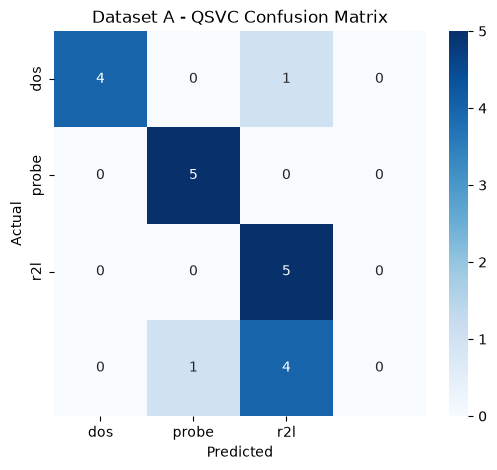

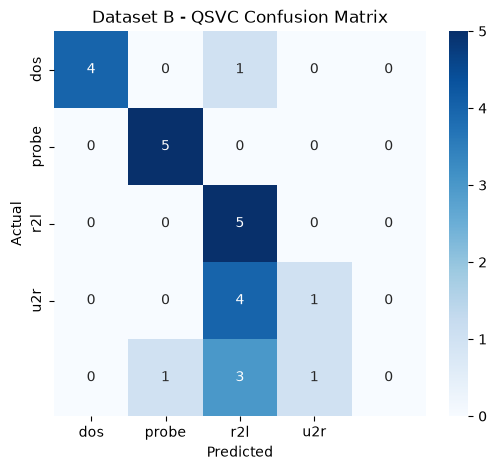

In [143]:
# Dataset A

cm1 = confusion_matrix(
    test_known_A["family"],
    y_pred1
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=qsvc1.classes_,
    yticklabels=qsvc1.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dataset A - QSVC Confusion Matrix")

plt.savefig(
    "qsvc_confusion_matrix_dataset_A.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Dataset B

cm2 = confusion_matrix(
    test_known_B["family"],
    y_pred2
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=qsvc2.classes_,
    yticklabels=qsvc2.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dataset B - QSVC Confusion Matrix")

plt.savefig(
    "qsvc_confusion_matrix_dataset_B.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [144]:
# Dataset A

comparison1 = pd.DataFrame({
    "Actual": test_known_A["family"],
    "Predicted": y_pred1
})

comparison1.head(30)

comparison1.to_csv(
    "qsvc_open_world_predictions_dataset_A.csv",
    index=False
)

In [145]:
# Dataset B

comparison2 = pd.DataFrame({
    "Actual": test_known_B["family"],
    "Predicted": y_pred2
})

comparison2.head(30)

comparison2.to_csv(
    "qsvc_open_world_predictions_dataset_B.csv",
    index=False
)

# **Conclusion**

This notebook extends the intrusion detection study from the closed-world setting to an open-world evaluation, where the trained QSVC models are tested on both previously known attack families and unseen attack types.


### Two quantum classifiers were evaluated:
1. Dataset A (DoS + Probe + R2L): **70%** accuracy on the representative evaluation subset.
2. Dataset B (DoS + Probe + R2L + U2R): **60%** accuracy on the representative evaluation subset.






The lower performance observed for Dataset B is primarily attributed to the **severe class imbalance caused by the limited availability of U2R samples (52 instances)** in the training dataset. This underrepresentation reduced the model's ability to effectively learn U2R characteristics, leading to a decrease in the overall classification accuracy.

As expected, the models correctly classified most known attack families, while the unknown attack category was not recognized because these attack types were absent during training, illustrating the inherent limitations of supervised closed-set quantum classifiers under open-world conditions.
Overall, these results establish a baseline for evaluating QSVC in an open-world intrusion detection setting and motivate future work on unknown attack detection and open-set recognition techniques.
